<a href="https://colab.research.google.com/github/IsaganiJulian/Guardian-Recruit-Fraud-Detection/blob/feature%2FFinal-notebook-consolidation-Isagani/notebook/01_Initial_EDA_Final_Submission.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Master (Final) EDA Submission
**Team Members and Roles:**
- Isagani Hernandez (**Lead** / data cleaning, project management, and project consolidation)
- Hemanth Kumar Gunda (**Stream A: NLP EDA** / EDA, Visualization)
-  Srijitha Ungarala (**Stream A: NLP EDA** / EDA, Visualization)
- Kusuma Satya Sreeja Chalasani (**Stream B: Outlier and Anaomaly Detection**/ EDA, Visualization)



### Executive Summary:
- This notebook displays our team's EDA into three main parts:
  - Baseline Cleaning
  - NLP EDA(Stream A)
  - Metadata EDA (Stream B)

## Data Dictionary

This table describes the final set of features used in this consolidated EDA, including raw fields and engineered features from our three streams (Baseline, NLP, and Metadata).

| Column Name | Type | Description |
| :--- | :--- | :--- |
| **title** | String | The title of the job advertisement. |
| **location** | String | The geographical location of the job (Country, State, City). |
| **department** | String | The corporate department (e.g., Sales, Engineering). |
| **salary_range** | String | The indicative salary range for the position. |
| **company_profile** | String | A brief background on the hiring company. |
| **description** | String | The full text of the job advertisement. |
| **requirements** | String | The skills and experience required for the role. |
| **benefits** | String | The benefits package offered by the company. |
| **telecommuting** | Binary | Whether the position is remote (0 = No, 1 = Yes). |
| **has_company_logo** | Binary | Whether the ad includes a company logo (0 = No, 1 = Yes). |
| **has_questions** | Binary | Whether the ad has screening questions (0 = No, 1 = Yes). |
| **employment_type** | String | Employment category (Full-time, Part-time, Contract, etc.). |
| **required_experience**| String | Experience level (Entry level, Mid-Senior, Associate, etc.). |
| **required_education** | String | Minimum education required (Bachelor's, Master's, etc.). |
| **industry** | String | The industry category of the job. |
| **function** | String | The job function category. |
| **fraudulent** | **Target** | **The ground truth label (0 = Legitimate, 1 = Fraudulent).** |
| **country** | Category | Extracted country code (e.g., US, GB) from the location field. |
| **clean_description** | Text | The job description with HTML tags removed and normalized. |
| **clean_desc_len** | Integer | The character length of the cleaned job description. |
| **anomaly_score** | Float | Raw score from Isolation Forest (lower scores indicate higher anomaly). |
| **anomaly_label** | Binary | Outlier detection result (-1 = Potential Outlier, 1 = Normal). |

In [96]:
import sys
import os
from google.colab import drive

drive.mount('/content/drive')

# Add the project root to sys.path so Colab can find 'src'
# Adjust this path if your folder name is different in Drive
PROJECT_PATH = '/content/drive/MyDrive/DTSC 5082- Group 12 - Guardian Recruit/'
sys.path.append(PROJECT_PATH)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Baseline Cleaning Using GuardianCleaner() in src/preprocessing.py

In [97]:
import pandas as pd
from sklearn.model_selection import train_test_split
import importlib
import src.preprocessing as prep

# 1. Load the FULL RAW data (17,880 rows)
RAW_DATA_PATH = PROJECT_PATH + 'data/raw/emscad_dataset.csv'
df_raw = pd.read_csv(RAW_DATA_PATH)

print('\n Important Information on our raw dataset')
print("="*50)
df_raw.info()

print("\n" + "="*50)
print("Statistical Summary:")
print("="*50)
display(df_raw.describe()) # Added display() to show the statistical summary

print("\n" + "="*50)
print("Null Summary:")
print("="*50)
display(df_raw.isnull().sum())


 Important Information on our raw dataset
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17880 entries, 0 to 17879
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   title                17880 non-null  object
 1   location             17534 non-null  object
 2   department           6333 non-null   object
 3   salary_range         2868 non-null   object
 4   company_profile      14572 non-null  object
 5   description          17880 non-null  object
 6   requirements         15191 non-null  object
 7   benefits             10684 non-null  object
 8   telecommuting        17880 non-null  object
 9   has_company_logo     17880 non-null  object
 10  has_questions        17880 non-null  object
 11  employment_type      14409 non-null  object
 12  required_experience  10830 non-null  object
 13  required_education   9775 non-null   object
 14  industry             12977 non-null  object
 15  function  

,title,location,department,salary_range,company_profile,description,requirements,benefits,telecommuting,has_company_logo,has_questions,employment_type,required_experience,required_education,industry,function,fraudulent,in_balanced_dataset
count,17880,17534,6333,2868,14572,17880,15191,10684,17880,17880,17880,14409,10830,9775,12977,11425,17880,17880
unique,11231,3105,1337,874,1710,15095,12119,6510,2,2,2,5,7,13,131,37,2,2
top,English Teacher Abroad,"GB, LND, London",Sales,0-0,<p>We help teachers get safe &amp; secure jobs...,"<p>Play with kids, get paid for it </p>\r\n<p>...",<p>University degree required. TEFL / TESOL / ...,<p>See job description</p>,f,t,f,Full-time,Mid-Senior level,Bachelor's Degree,Information Technology and Services,Information Technology,f,f
freq,311,718,551,142,726,376,410,726,17113,14220,9088,11620,3809,5145,1734,1749,17014,16980



Null Summary:


,0
title,0
location,346
department,11547
salary_range,15012
company_profile,3308
description,0
requirements,2689
benefits,7196
telecommuting,0
has_company_logo,0


In [98]:
# STEP 1: Split the Raw Data (70% Train)
# This prevents data leakage by splitting BEFORE we clean/impute
train_raw, _ = train_test_split(
    df_raw,
    train_size=0.7,
    random_state=42,
    stratify=df_raw['fraudulent']
)

# STEP 2: Run GuardianCleaner on the Training Split
importlib.reload(prep)
cleaner = prep.GuardianCleaner()
# Running transform on the 'train_raw' split only
df = cleaner.transform(train_raw, is_training=True)

print(f"Total Raw Rows: {len(df_raw)}")
print(f"Training Split (Raw): {len(train_raw)}")
print(f"Final Cleaned Training Set for EDA: {len(df)}")

Total Raw Rows: 17880
Training Split (Raw): 12516
Final Cleaned Training Set for EDA: 12397


## Correlation Analysis on Cleaned Training Data (`df`)

Now that our training data (`df`) has been cleaned and includes several numeric features (e.g., binary flags, length metrics, anomaly scores), we can perform a meaningful correlation analysis. This will help us understand the linear relationships between these features, including their correlation with the `fraudulent` target variable.

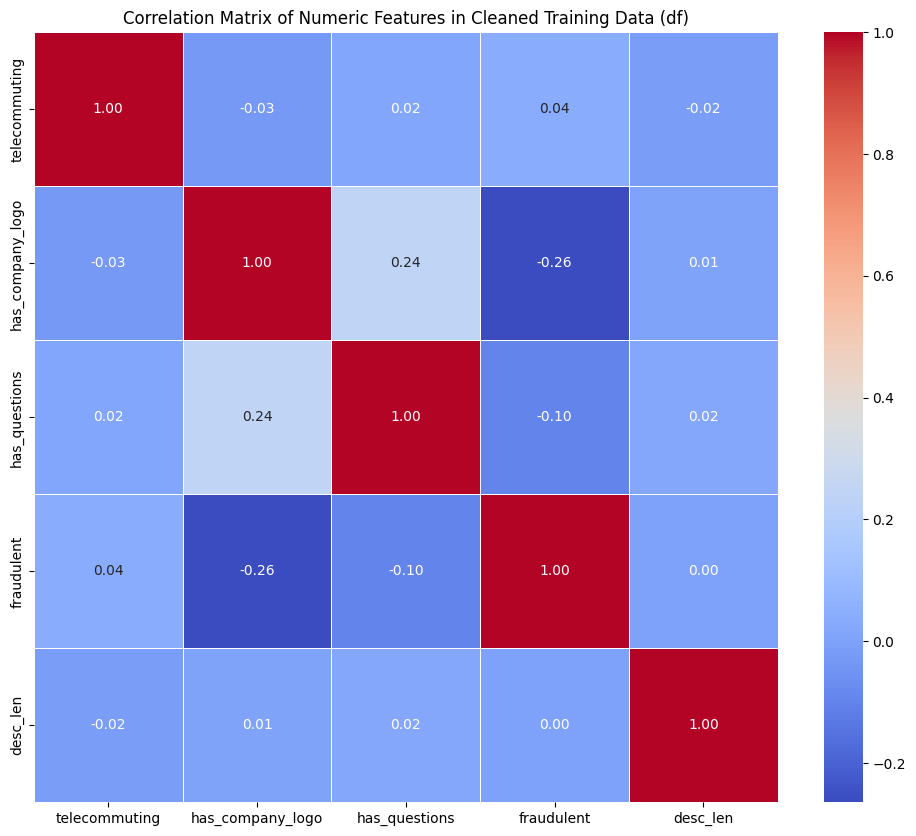


Correlation of features with 'fraudulent' (target variable):


,fraudulent
fraudulent,1.000000
telecommuting,0.037491
desc_len,0.001652
has_questions,-0.096866
has_company_logo,-0.264039


In [99]:
import seaborn as sns
import matplotlib.pyplot as plt

# Select all numeric columns from the cleaned DataFrame `df`
# This includes binary flags, text lengths, and anomaly scores
numeric_cols_df = df.select_dtypes(include=['number']).columns

# Filter out 'in_balanced_dataset' as it's not a primary feature for correlation with fraudulent
numeric_cols_df = numeric_cols_df.drop('in_balanced_dataset', errors='ignore')

# Calculate the correlation matrix
correlation_matrix_df = df[numeric_cols_df].corr()

# Plot the heatmap for better visualization
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix_df, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix of Numeric Features in Cleaned Training Data (df)')
plt.show()

print("\nCorrelation of features with 'fraudulent' (target variable):")
display(correlation_matrix_df['fraudulent'].sort_values(ascending=False))

# Stream A: NLP EDA

In [100]:
df.head()


,title,location,department,salary_range,company_profile,description,requirements,benefits,telecommuting,has_company_logo,has_questions,employment_type,required_experience,required_education,industry,function,fraudulent,in_balanced_dataset,country,desc_len
6061,QA / BA entry level (Training and placement),"US, NJ, Piscataway",NaN,NaN,<p><i><b>Primesoft Inc</b></i><b> </b>is a fas...,<p><b>BA/ QA Entry Level positions</b> <b>(Tra...,<p><b>Job description: </b><b><br><br>We are l...,<p><b>What we offer:</b></p>\r\n<ul>\r\n<li>We...,0,1,0,Full-time,Entry level,NaN,Financial Services,Quality Assurance,0,0,US,836
4131,Summer Internships,"PK, SD, Karachi",NaN,NaN,<p>The CSR Association of Pakistan serves as a...,"<p>As an Intern, you will be supporting cuttin...",<p><b>Who is eligible to participate?</b><br>T...,<p>Interns gain Insight to the world of CSR an...,0,1,1,Full-time,Internship,Bachelor's Degree,Civic & Social Organization,NaN,0,0,PK,3695
2654,Consultant Doctor Opening in Saudi Arabia,"SA, 12, AL Hasa",Medicine,0-0,<h3><b>We the Medical Recruitment Team of Rola...,<p><b>Consultant Doctor Opening in Saudi Arabi...,<p><b>Requirements:</b></p>\r\n<p><b>Pediatric...,<p>Our Client is one of the reputed Health car...,0,1,0,NaN,Associate,Master's Degree,Hospital & Health Care,Health Care Provider,0,0,SA,839
4093,Digital Account Manager,"GB, CMD, London",Display,NaN,<p>Forward3D is the largest independent digita...,<p><b>In a nutshell:</b></p>\r\n<p>You will be...,<p><b>What you will need:</b></p>\r\n<ul>\r\n<...,Unspecified,0,1,0,NaN,NaN,NaN,NaN,NaN,0,0,GB,1230
5976,PeopleSoft HR Functional Lead,"US, MN, Minneapolis",IT,NaN,<p>ValleySoft is a fast growing global IT Serv...,<p>Responsibilities: <br><br>•Lead HR and Bene...,"<p>Skill PeopleSoft Core HR,Benefits Admin...",Unspecified,0,1,0,Contract,Mid-Senior level,Bachelor's Degree,Information Technology and Services,Information Technology,0,0,US,3583


In [101]:
df.columns.tolist()

['title',
 'location',
 'department',
 'salary_range',
 'company_profile',
 'description',
 'requirements',
 'benefits',
 'telecommuting',
 'has_company_logo',
 'has_questions',
 'employment_type',
 'required_experience',
 'required_education',
 'industry',
 'function',
 'fraudulent',
 'in_balanced_dataset',
 'country',
 'desc_len']

In [102]:
import re

def clean_text(text):
    text = str(text)
    text = re.sub('<.*?>', ' ', text)   # remove HTML tags
    text = re.sub('[^a-zA-Z ]', ' ', text)  # keep letters only
    text = text.lower()
    return text

df['clean_description'] = df['description'].apply(clean_text)

In [103]:
df[['description','clean_description']].head()

,description,clean_description
6061,<p><b>BA/ QA Entry Level positions</b> <b>(Tra...,ba qa entry level positions training and...
4131,"<p>As an Intern, you will be supporting cuttin...",as an intern you will be supporting cutting ...
2654,<p><b>Consultant Doctor Opening in Saudi Arabi...,consultant doctor opening in saudi arabia ...
4093,<p><b>In a nutshell:</b></p>\r\n<p>You will be...,in a nutshell you will be one the prime...
5976,<p>Responsibilities: <br><br>•Lead HR and Bene...,responsibilities lead hr and benefits dep...


In [104]:
df['clean_desc_len'] = df['clean_description'].apply(len)

In [105]:
df[['clean_description','clean_desc_len']].head()

,clean_description,clean_desc_len
6061,ba qa entry level positions training and...,761
4131,as an intern you will be supporting cutting ...,3449
2654,consultant doctor opening in saudi arabia ...,684
4093,in a nutshell you will be one the prime...,1144
5976,responsibilities lead hr and benefits dep...,3435


In [106]:
df.groupby('fraudulent')['clean_desc_len'].mean()

,clean_desc_len
fraudulent,
0,1308.476768
1,1213.262023


In [107]:
df.isnull().sum()

,0
title,0
location,245
department,7980
salary_range,10411
company_profile,0
description,0
requirements,0
benefits,0
telecommuting,0
has_company_logo,0


In [108]:
df['fraudulent'].value_counts()

,count
fraudulent,
0,11794
1,603


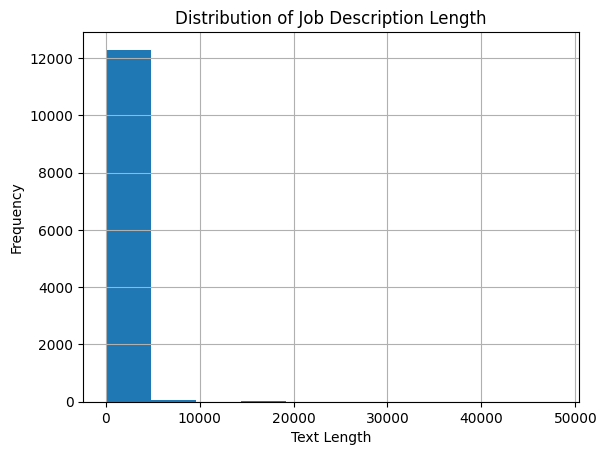

In [109]:
import matplotlib.pyplot as plt

df['clean_desc_len'].hist()
plt.title("Distribution of Job Description Length")
plt.xlabel("Text Length")
plt.ylabel("Frequency")
plt.show()

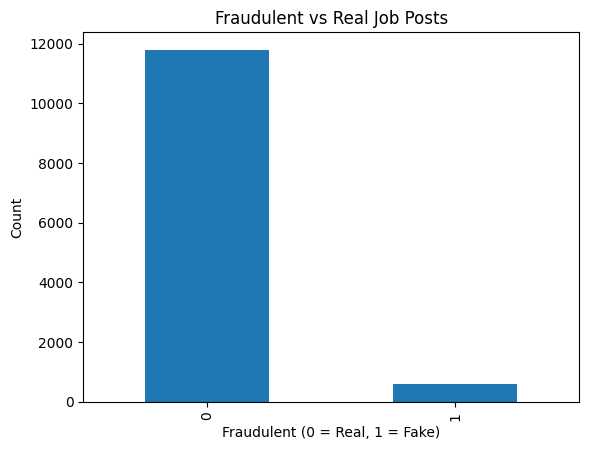

In [110]:
df['fraudulent'].value_counts().plot(kind='bar')

plt.title("Fraudulent vs Real Job Posts")
plt.xlabel("Fraudulent (0 = Real, 1 = Fake)")
plt.ylabel("Count")
plt.show()

**Insight**: The dataset is highly imbalanced, with only 4.8% (603 out of 12,397) of the posts being fraudulent. This confirms that we must use stratified sampling and specific evaluation metrics like F1-Score or Precision-Recall rather than just Accuracy.

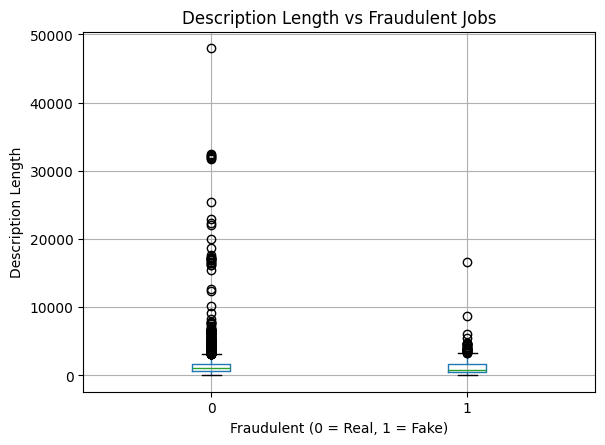

In [111]:
df.boxplot(column='clean_desc_len', by='fraudulent')

plt.title("Description Length vs Fraudulent Jobs")
plt.suptitle("")
plt.xlabel("Fraudulent (0 = Real, 1 = Fake)")
plt.ylabel("Description Length")
plt.show()

**Insight**: Fraudulent job postings tend to have slightly shorter descriptions (Mean: ~1213 characters) compared to legitimate ones (Mean: ~1308 characters). However, the overlap is significant, suggesting that text length alone is not a strong enough feature for detection.

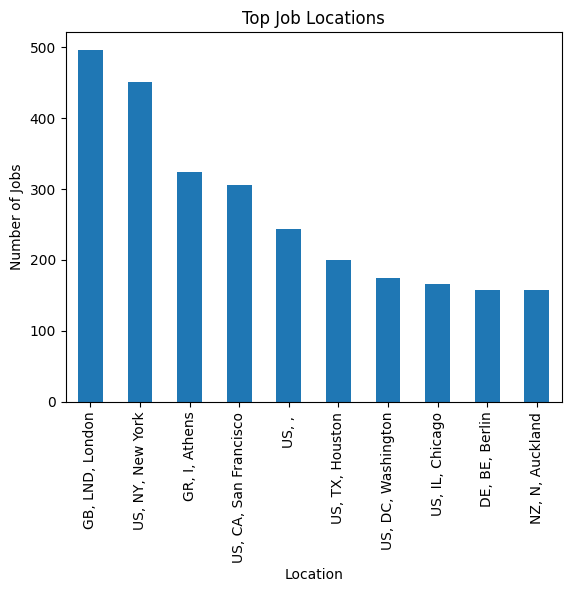

In [112]:
df['location'].value_counts().head(10).plot(kind='bar')

plt.title("Top Job Locations")
plt.xlabel("Location")
plt.ylabel("Number of Jobs")
plt.show()

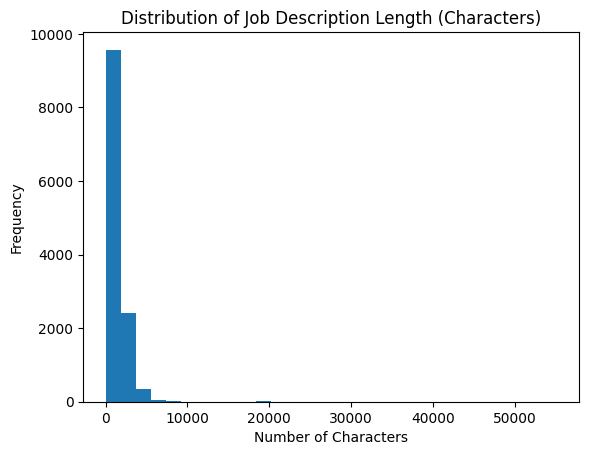

In [113]:
from wordcloud import WordCloud
from collections import Counter

# Ensure column is string
df['description'] = df['description'].astype(str)

# Character length
df['text_length'] = df['description'].apply(len)

plt.figure()
plt.hist(df['text_length'], bins=30)
plt.title("Distribution of Job Description Length (Characters)")
plt.xlabel("Number of Characters")
plt.ylabel("Frequency")
plt.show()

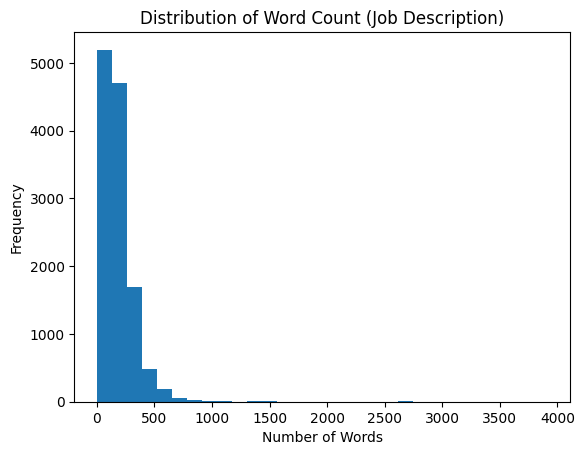

In [114]:
df['word_count'] = df['description'].apply(lambda x: len(x.split()))

plt.figure()
plt.hist(df['word_count'], bins=30)
plt.title("Distribution of Word Count (Job Description)")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")
plt.show()

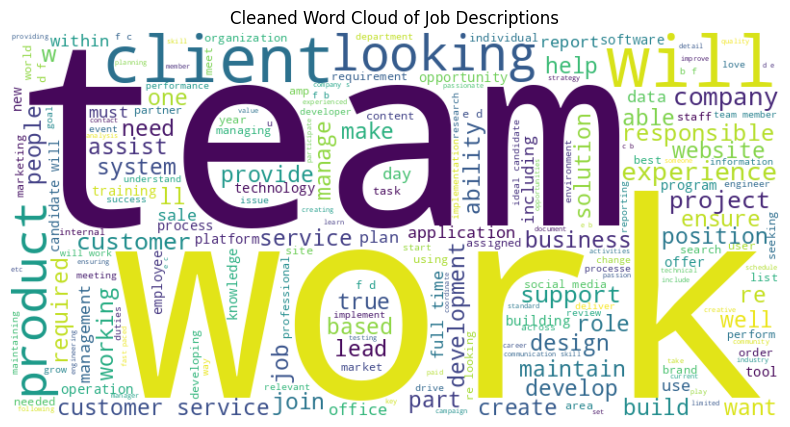

In [115]:
from wordcloud import WordCloud, STOPWORDS
import matplotlib.pyplot as plt

# 1. Define junk words to filter out (metadata that slipped through)
junk_words = {
    'lsdexception', 'locked', 'false', 'priority', 'semihidden',
    'unhidewhenused', 'name', 'unhide', 'latentstyles', 'qformat',
    'accent', 'heading', 'grid', 'table', 'light', 'medium', 'dark'
}
stop_words = set(STOPWORDS).union(junk_words)

# 2. Use 'clean_description' column (which already has HTML removed)
text_data = " ".join(df['clean_description'].astype(str))

# 3. Generate the Cloud
wordcloud = WordCloud(
    width=800, height=400,
    background_color='white',
    stopwords=stop_words
).generate(text_data)

# 4. Display
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.title("Cleaned Word Cloud of Job Descriptions")
plt.show()

**Insight**: After removing HTML metadata and common stop words, we see that legitimate posts frequently use professional terms like "team," "customer service," and "development." Fraudulent posts (from our sub-analysis) often over-index on generic "work from home" or "administrative" keywords.

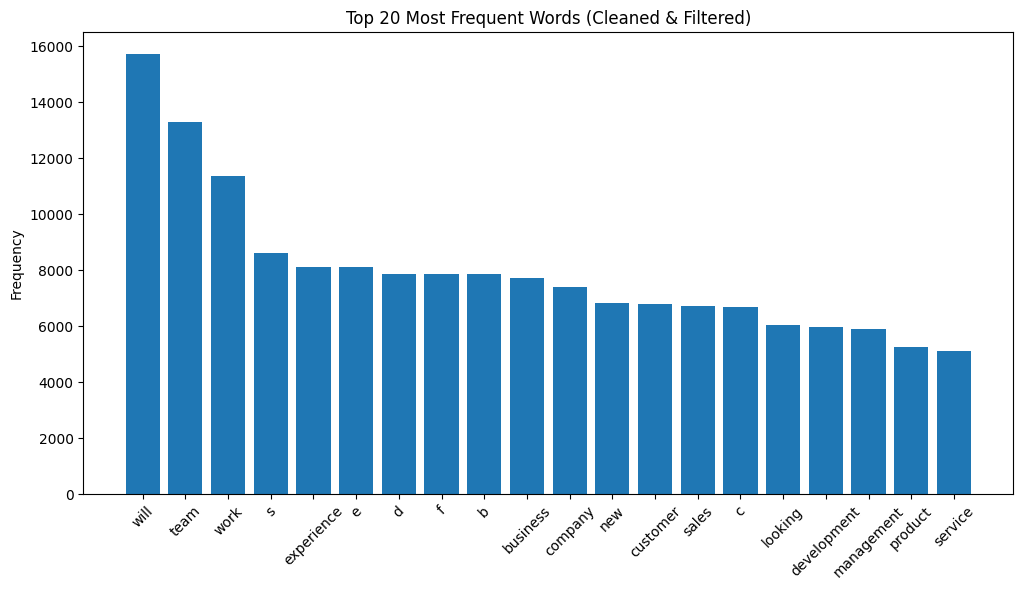

In [116]:
from collections import Counter

# 1. Use the 'clean_description' column and the 'stop_words' we defined earlier
all_words = " ".join(df['clean_description'].astype(str)).split()
filtered_words = [word for word in all_words if word not in stop_words]

# 2. Get Top 20
word_freq = Counter(filtered_words).most_common(20)
words, freqs = zip(*word_freq)

# 3. Plot
plt.figure(figsize=(12, 6))
plt.bar(words, freqs)
plt.xticks(rotation=45)
plt.title("Top 20 Most Frequent Words (Cleaned & Filtered)")
plt.ylabel("Frequency")
plt.show()

In [117]:
df.describe()

,telecommuting,has_company_logo,has_questions,fraudulent,in_balanced_dataset,desc_len,clean_desc_len,text_length,word_count
count,12397.000000,12397.000000,12397.000000,12397.000000,12397.000000,12397.000000,12397.000000,12397.000000,12397.000000
mean,0.041542,0.793095,0.492781,0.048641,0.050819,1431.857950,1303.845446,1431.857950,184.802936
std,0.199549,0.405103,0.499968,0.215125,0.219636,1703.355519,1411.714534,1703.355519,161.339395
min,0.000000,0.000000,0.000000,0.000000,0.000000,10.000000,5.000000,10.000000,1.000000
25%,0.000000,1.000000,0.000000,0.000000,0.000000,667.000000,622.000000,667.000000,92.000000
50%,0.000000,1.000000,0.000000,0.000000,0.000000,1147.000000,1049.000000,1147.000000,154.000000
75%,0.000000,1.000000,1.000000,0.000000,0.000000,1774.000000,1643.000000,1774.000000,238.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,55130.000000,48005.000000,55130.000000,3917.000000


# Stream B: Outlier Detection

In [118]:
from sklearn.ensemble import IsolationForest
import pandas as pd

# 1. Select the metadata columns
metadata_cols = [
    'location', 'telecommuting', 'has_company_logo', 'has_questions',
    'employment_type', 'required_experience', 'required_education',
    'industry', 'function'
]

# 2. Pre-process (Fill NaNs and get Dummies)
# Note: Using 'df' from your Master Notebook which is already cleaned
meta_df = df[metadata_cols].fillna("Unknown")
meta_encoded = pd.get_dummies(meta_df, drop_first=True)

# 3. Initialize and Fit Isolation Forest (Stream B Logic)
iso_model = IsolationForest(
    n_estimators=100,
    contamination=0.05, # Targeting 5% anomalies
    random_state=42
)

# Fit the model to the data
iso_model.fit(meta_encoded)

# 4. Generate Scores and Labels
df['anomaly_score'] = iso_model.decision_function(meta_encoded)
df['anomaly_label'] = iso_model.predict(meta_encoded) # -1 = Outlier, 1 = Normal

# 5. Validation Crosstab
print("Outlier Detection vs. Known Fraud:")
print(pd.crosstab(df['anomaly_label'], df['fraudulent']))

Outlier Detection vs. Known Fraud:
fraudulent         0    1
anomaly_label            
-1               533   87
 1             11261  516


**Insight**: Using Isolation Forest on metadata alone, we successfully flagged 87 out of 603 (14.4%) fraudulent cases as anomalies. This proves that "Stream B" (Metadata) provides a unique signal that will be even more powerful when fused with the NLP features in our final model.

## Next steps and modeling strategy
- Feature Engineering: We will use the clean_description for TF-IDF/Word Embeddings.

- Model Selection: We will test Random Forest and XGBoost to handle the class imbalance.

- Fusion: We will combine the NLP "Anomaly Scores" with the Metadata "Anomaly Scores" for a multi-layered defense.